![image info](https://raw.githubusercontent.com/albahnsen/MIAD_ML_and_NLP/main/images/banner_1.png)

# Taller: Redes Neuronales

En este taller podrán poner en práctica sus conocimientos sobre la construcción e implementación de redes neuronales de una capa y multicapa. El taller está constituido por 4 puntos, en los cuales deberan seguir las intrucciones de cada numeral para su desarrollo.

## Datos predicción probabilidad de admisión a la universidad

En este taller se usará el conjunto de datos de admisiones a una universidad proveniente de la base de datos de Kaggle. Cada observación contiene la probabilidad de que un estudiante sea admitido por la universidad, dadas distintas variables predictoras como el puntaje del examén TOEFL y GRE, el promedio (GPA), entre otras. El objetivo es predecir la probabilidad de admissión de cada estudiante. Para más detalles pueden visitar el siguiente enlace: [datos](https://www.kaggle.com/mohansacharya/graduate-admissions).

In [14]:
import warnings
warnings.filterwarnings('ignore')

In [42]:
# Importación librerías
import numpy as np
import keras
import pandas as pd
import matplotlib.pyplot as plt

%matplotlib inline

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

from keras import initializers
from keras import optimizers

from keras.models import Sequential
from keras.layers import Dense
from keras.layers import Dropout

from livelossplot import PlotLossesKeras

from tensorflow.keras.optimizers import Adam, RMSprop, Nadam
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras import backend as K

In [43]:
# Carga de datos de archivo .csv
data = pd.read_csv('https://raw.githubusercontent.com/albahnsen/MIAD_ML_and_NLP/main/datasets/universityGraduateAdmissions.csv', index_col=0)
data.head()

,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit
Serial No.,,,,,,,,
1,337,118,4,4.5,4.5,9.65,1,0.92
2,324,107,4,4.0,4.5,8.87,1,0.76
3,316,104,3,3.0,3.5,8.00,1,0.72
4,322,110,3,3.5,2.5,8.67,1,0.80
5,314,103,2,2.0,3.0,8.21,0,0.65


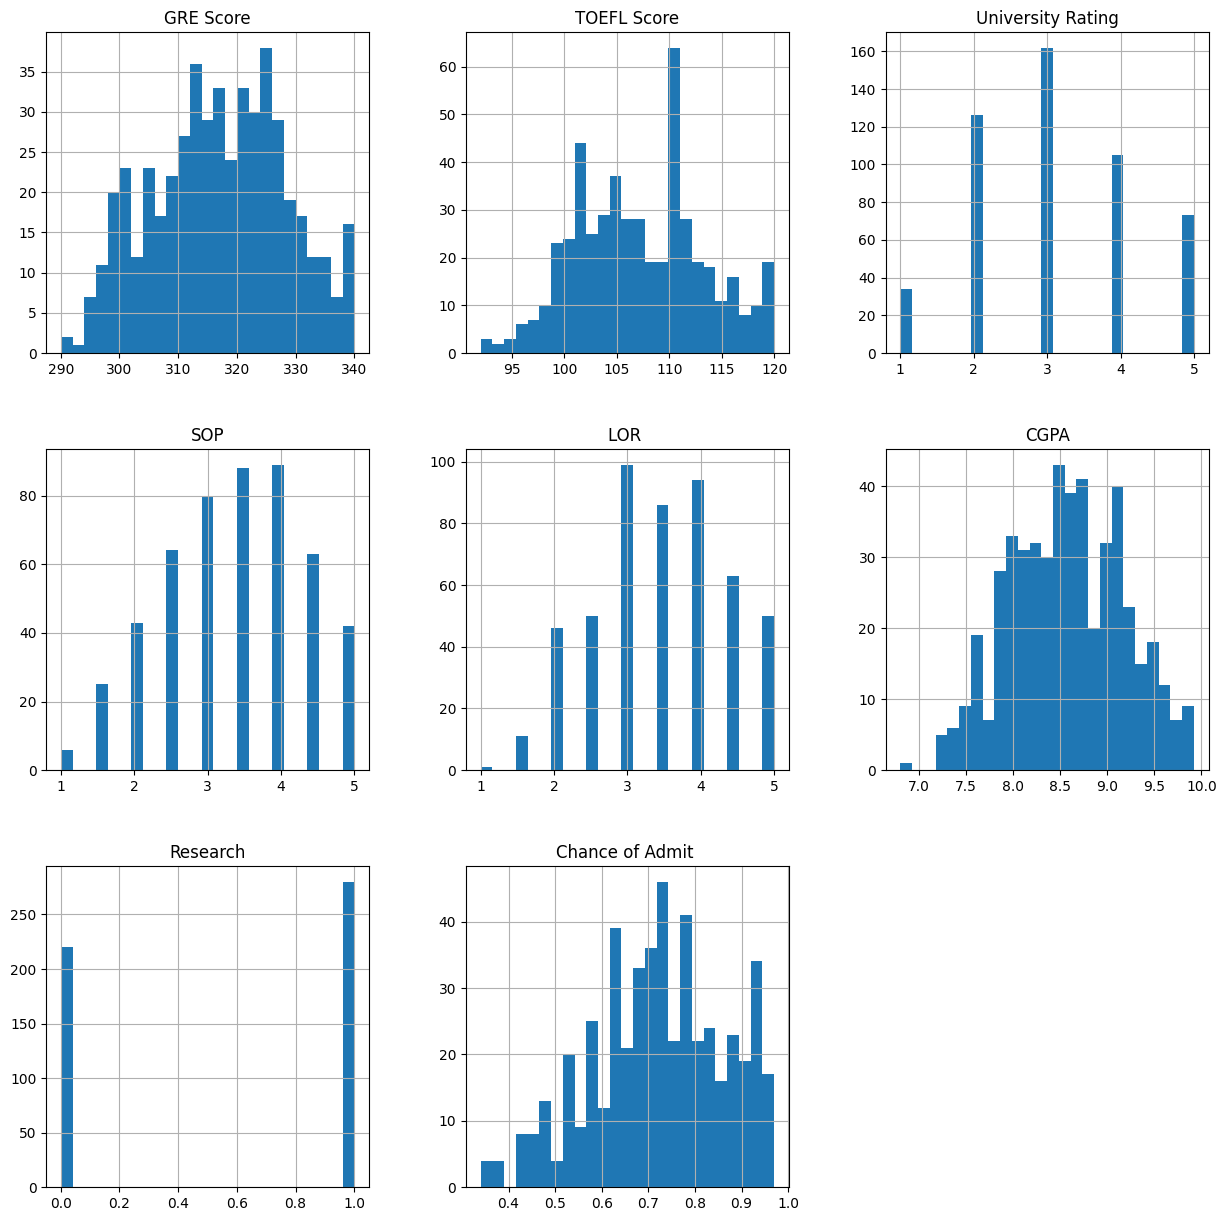

In [44]:
# Hitogramas de las varaibles del dataset
data.hist(bins=25, figsize=(15,15))
plt.show()

In [45]:
# Definición de variables predictoras (X)
X = data.drop(data.columns[-1], axis=1)
# Definición de variable de interés (y)
Y = data[data.columns[-1]]

In [46]:
# Separación de variables predictoras (X) y variable de interés (y) en set de entrenamiento y test usandola función train_test_split
xTrain, xTest, yTrain, yTest = train_test_split(X,Y,test_size=0.3, random_state=22)

## Punto 1 - Red Neuronal de una capa

En la celda 1 creen una **red neuronal de una capa** con la librería Keras, que prediga la probabilidad de admisión de los estudiantes, usando los sets de entrenamiento y test definidos anteriormente. Pueden usar la función de perdida, el optimizador y el número de épocas que consideren pertinentes para el modelo, justificando su selección. Finalmente, grafiquen la pérdida del modelo vs el número de épocas en el set de entrenamiento y validación, y presenten el desempeño del modelo con las métricas error absoluto medio (MAE) y error cuadrático medio (MSE).

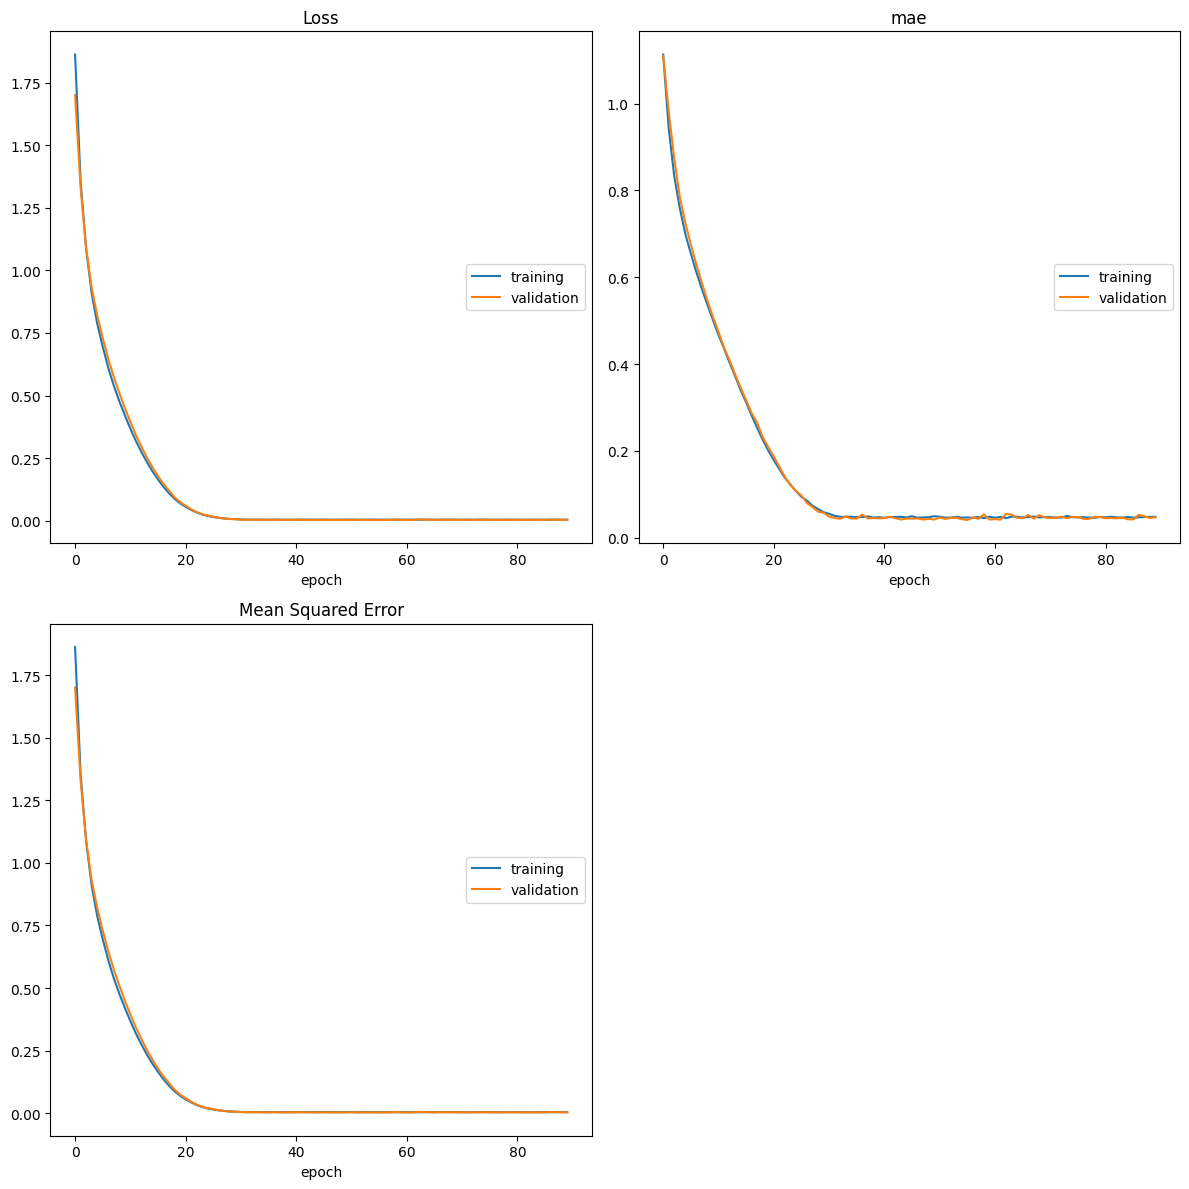

Loss
	training         	 (min:    0.004, max:    1.862, cur:    0.004)
	validation       	 (min:    0.003, max:    1.701, cur:    0.004)
mae
	training         	 (min:    0.045, max:    1.113, cur:    0.048)
	validation       	 (min:    0.041, max:    1.110, cur:    0.047)
Mean Squared Error
	training         	 (min:    0.004, max:    1.862, cur:    0.004)
	validation       	 (min:    0.003, max:    1.701, cur:    0.004)
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - loss: 0.0042 - mae: 0.0482 - mse: 0.0042 - val_loss: 0.0036 - val_mae: 0.0471 - val_mse: 0.0036

Mejor época (restaurada): 60
Pérdida de validación en esa época: 0.003074
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 

Resultados en test:
MAE (1 capa): 0.04191051955223083
MSE (1 capa): 0.003353509950181495


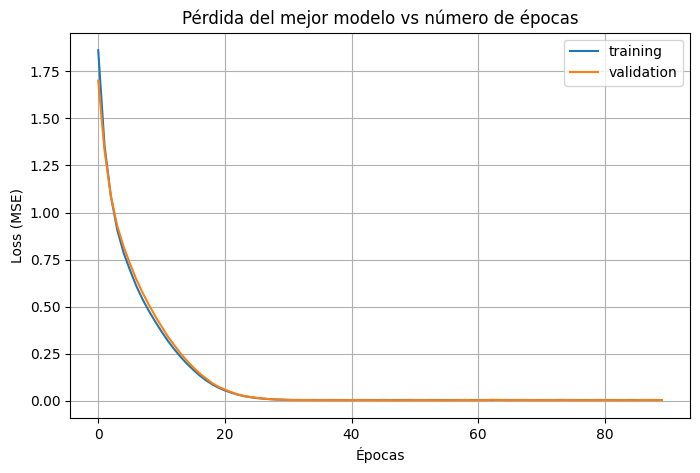

In [49]:
# Celda 1

# variables numericas continuas
numeric_features = [
    'GRE Score',
    'TOEFL Score',
    'University Rating',
    'SOP',
    'LOR ',
    'CGPA'
]

# variable binaria
binary_features = ['Research']

# preprocesamiento
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('bin', 'passthrough', binary_features)
    ]
)

X_train_processed = preprocessor.fit_transform(xTrain)
X_test_processed = preprocessor.transform(xTest)

# lista de optimizadores para comparar
optimizer_grid = {
    'Adam': Adam,
    'RMSprop': RMSprop,
    'Nadam': Nadam
}

# valores de learning rate a evaluar
learning_rates = [0.001, 0.005, 0.01]

# lista para almacenar los resultados
resultados_grid = []

# función para crear la red neuronal de una capa
def crear_modelo(input_dim, optimizer_class, learning_rate):
    model = Sequential([
        Dense(
            units=1,
            activation='linear',
            input_shape=(input_dim,)
        )
    ])

    # compilar modelo
    model.compile(
        optimizer=optimizer_class(learning_rate=learning_rate),
        loss='mse',
        metrics=['mae', 'mse']
    )

    return model

# grid search
for nombre_optimizador, optimizer_class in optimizer_grid.items():
    for lr in learning_rates:
        K.clear_session()

        # crear modelo
        model = crear_modelo(X_train_processed.shape[1], optimizer_class, lr)

        # callback de parada temprana
        early_stop = EarlyStopping(
            monitor='val_loss',
            patience=30,
            restore_best_weights=True
        )

        # entrenar modelo
        history = model.fit(
            X_train_processed,
            yTrain,
            verbose=0,
            epochs=100,
            batch_size=32,
            validation_split=0.2,
            callbacks=[early_stop]
        )

        # mejor epoca segun la perdida de validacion
        best_idx = np.argmin(history.history['val_loss'])
        best_epoch = best_idx + 1

        # metricas de validacion en la mejor epoca
        best_val_loss = history.history['val_loss'][best_idx]
        best_val_mae = history.history['val_mae'][best_idx]
        best_val_mse = history.history['val_mse'][best_idx]

        # guardar resultados
        resultados_grid.append({
            'optimizador': nombre_optimizador,
            'learning_rate': lr,
            'best_epoch': best_epoch,
            'val_loss': best_val_loss,
            'val_mae': best_val_mae,
            'val_mse': best_val_mse
        })

# dataframe con resultados
resultados_grid = pd.DataFrame(resultados_grid)

# ordenar por MSE y luego por MAE
resultados_grid = resultados_grid.sort_values(
    by=['val_mse', 'val_mae'],
    ascending=True
).reset_index(drop=True)

print("Resultados del grid search:")
print(resultados_grid)

# mejor configuracion segun MSE y MAE
mejor_config = resultados_grid.iloc[0]

print("\nMejor configuración encontrada:")
print("Optimizador:", mejor_config['optimizador'])
print("Learning rate:", mejor_config['learning_rate'])
print("Mejor época:", int(mejor_config['best_epoch']))
print("MSE de validación:", mejor_config['val_mse'])
print("MAE de validación:", mejor_config['val_mae'])

# volver a entrenar el mejor modelo
K.clear_session()

# seleccionar el optimizador ganador
if mejor_config['optimizador'] == 'Adam':
    optimo = Adam
elif mejor_config['optimizador'] == 'RMSprop':
    optimo = RMSprop
else:
    optimo = Nadam

# crear modelo final con la mejor configuracion
best_model = Sequential([
    Dense(
        units=1,
        activation='linear',
        input_shape=(X_train_processed.shape[1],)
    )
])

# compilar modelo final
best_model.compile(
    optimizer=optimo(learning_rate=float(mejor_config['learning_rate'])),
    loss='mse',
    metrics=['mae', 'mse']
)

# callback de parada temprana
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=30,
    restore_best_weights=True
)

# entrenar modelo final
history_best = best_model.fit(
    X_train_processed,
    yTrain,
    verbose=1,
    epochs=100,
    batch_size=32,
    validation_split=0.2,
    callbacks=[
        PlotLossesKeras(),
        early_stop
    ]
)

# mejor epoca del modelo final
best_epoch_final = np.argmin(history_best.history['val_loss']) + 1
best_val_loss_final = np.min(history_best.history['val_loss'])

print(f"\nMejor época (restaurada): {best_epoch_final}")
print(f"Pérdida de validación en esa época: {best_val_loss_final:.6f}")

# predicciones sobre test
y_pred = best_model.predict(X_test_processed).flatten()

# recortar predicciones al rango de probabilidad
y_pred = np.clip(y_pred, 0, 1)

# metricas finales en test
mae_1capa = mean_absolute_error(yTest, y_pred)
mse_1capa = mean_squared_error(yTest, y_pred)

print("\nResultados en test:")
print("MAE (1 capa):", mae_1capa)
print("MSE (1 capa):", mse_1capa)

# grafica de perdida vs epocas
plt.figure(figsize=(8, 5))
plt.plot(history_best.history['loss'], label='training')
plt.plot(history_best.history['val_loss'], label='validation')
plt.title('Pérdida del mejor modelo vs número de épocas')
plt.xlabel('Épocas')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.grid(True)
plt.show()

**Justificación de la configuración del modelo**

Se implementó una red neuronal de una única capa sin capa oculta, con una neurona de salida y activación lineal. La naturaleza del problema (regresión de una probabilidad continua) hace adecuada la activación lineal, recortando posteriormente las predicciones al intervalo $[0,1]$.

Dada la sensibilidad del rendimiento de las redes neuronales a la elección del optimizador y la tasa de aprendizaje, se llevó a cabo una búsqueda sistemática sobre una cuadrícula de hiperparámetros compuesta por:

- **Optimizadores considerados:** Adam, RMSprop y Nadam.
- **Tasas de aprendizaje evaluadas:** $0.001$, $0.005$ y $0.01$.

Para cada combinación se entrenó la red durante un máximo de $100$ épocas, utilizando *early stopping* con paciencia de $30$ épocas monitorizando la pérdida de validación, y se seleccionó aquella configuración que alcanzara el menor error cuadrático medio (MSE) y error absoluto medio (MAE) en validación.

- **Función de pérdida:** En todos los casos se empleó MSE,  
  $$ \mathcal{L}_{\text{MSE}} = \frac{1}{n}\sum_{i=1}^{n}(y_i - \hat{y}_i)^2, $$  
  por ser la métrica clásica en regresión, diferenciable y con penalización cuadrática que favorece predicciones cercanas a los valores reales.

- **Optimizador y tasa de aprendizaje seleccionados:** La búsqueda determinó que la combinación óptima era **Adam** con **learning rate $0.01$**. Este optimizador adapta la tasa de aprendizaje por parámetro, combinando el momento y la normalización por la magnitud de los gradientes, lo que acelera la convergencia y suele ser robusto ante la elección inicial de hiperparámetros.

- **Número de épocas y regularización:** El entrenamiento final se ejecutó con $100$ épocas como máximo, aplicando *early stopping* con paciencia $30$; la mejor época resultante fue la $60$, lo que indica que el modelo convergió sin sobreajustar. Este mecanismo evita tener que fijar manualmente un número exacto de iteraciones y selecciona los pesos con mejor generalización.

Los resultados en prueba fueron:  
$$\text{MAE} = 0.0419,\quad \text{MSE} = 0.00335.$$

La gráfica de evolución de la pérdida muestra un descenso monotónico y estable tanto en entrenamiento como en validación, confirmando que el modelo aprendió correctamente sin signos de sobreajuste.

*Nota metodológica:* La búsqueda en cuadrícula introduce un sesgo de selección controlado, pero garantiza que la configuración escogida es la que mejor se comporta dentro del espacio explorado. La aleatoriedad de la inicialización y la división de los datos se mitiga mediante la validación cruzada interna (validación del $20\%$ en cada ejecución) y la restauración de los mejores pesos.

## Punto 2 - Red Neuronal multicapa

En la celda 2 creen una **red neuronal con dos capas** con la librería Keras, que prediga la probabilidad de admisión de los estudiantes usando los sets de entrenamiento y test definidos anteriormente. Pueden usar la función de perdida, el optimizador, el número de épocas y el número de neuronas que consideren pertinentes para el modelo, justificando su selección. Finalmente, grafiquen la pérdida del modelo vs el número de épocas en el set de entrenamiento y validación, y presenten el desempeño del modelo con las métricas error absoluto medio (MAE) y error cuadrático medio (MSE).

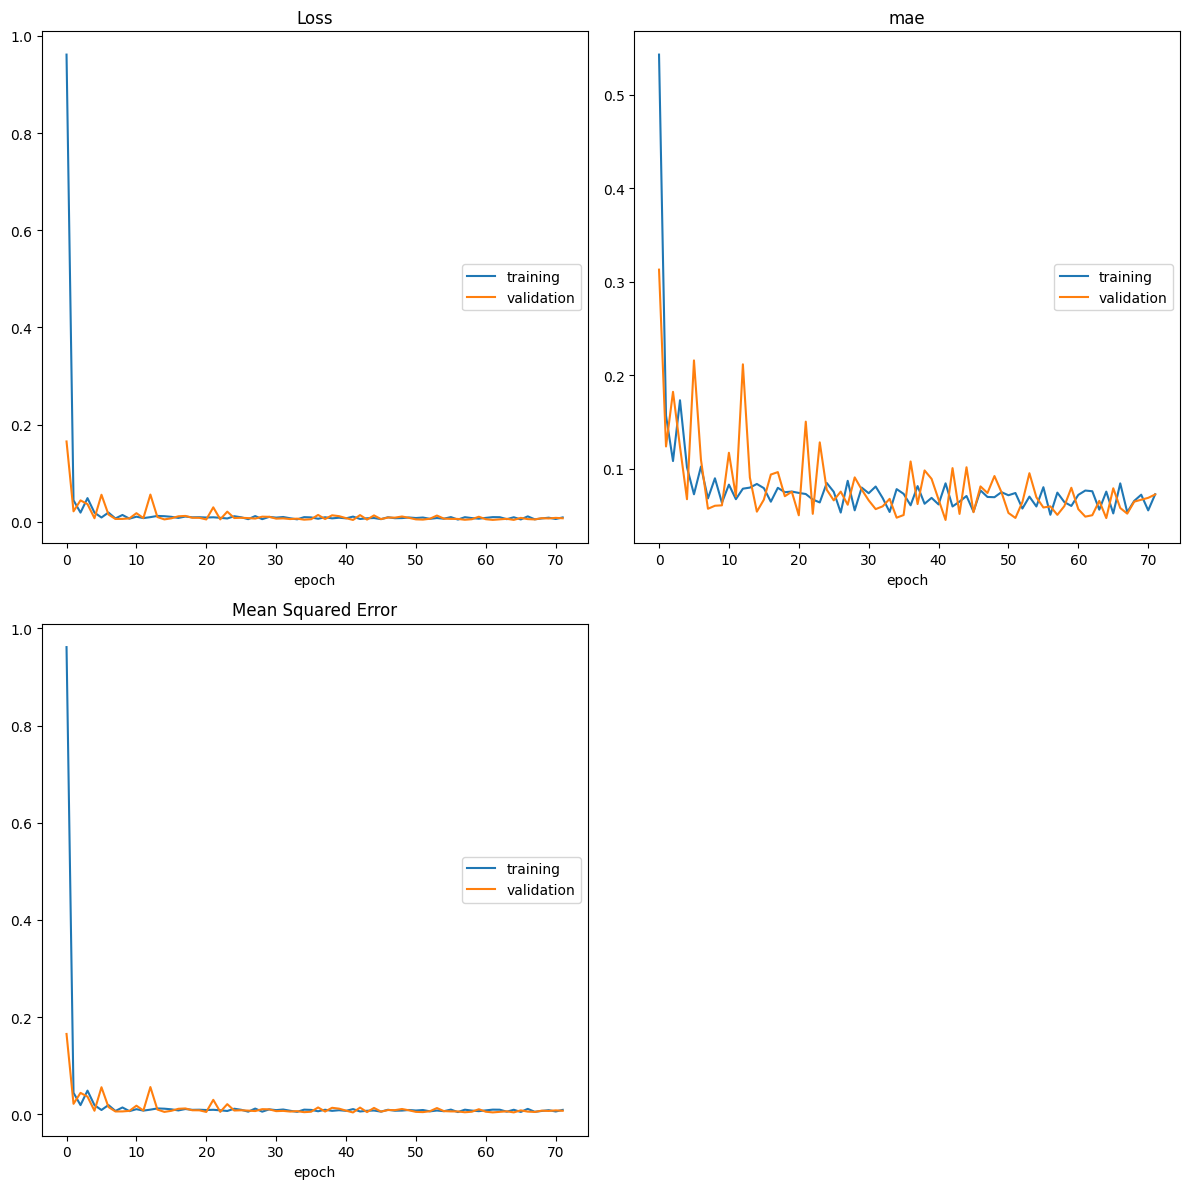

Loss
	training         	 (min:    0.005, max:    0.961, cur:    0.009)
	validation       	 (min:    0.004, max:    0.165, cur:    0.007)
mae
	training         	 (min:    0.051, max:    0.543, cur:    0.073)
	validation       	 (min:    0.045, max:    0.313, cur:    0.073)
Mean Squared Error
	training         	 (min:    0.005, max:    0.961, cur:    0.009)
	validation       	 (min:    0.004, max:    0.165, cur:    0.007)
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - loss: 0.0090 - mae: 0.0729 - mse: 0.0090 - val_loss: 0.0072 - val_mae: 0.0727 - val_mse: 0.0072

Mejor epoca (restaurada): 42
Perdida de validacion en esa epoca: 0.003738
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 

Resultados en test:
MAE (2 capas): 0.045668325201670336
MSE (2 capas): 0.0038545031594340536


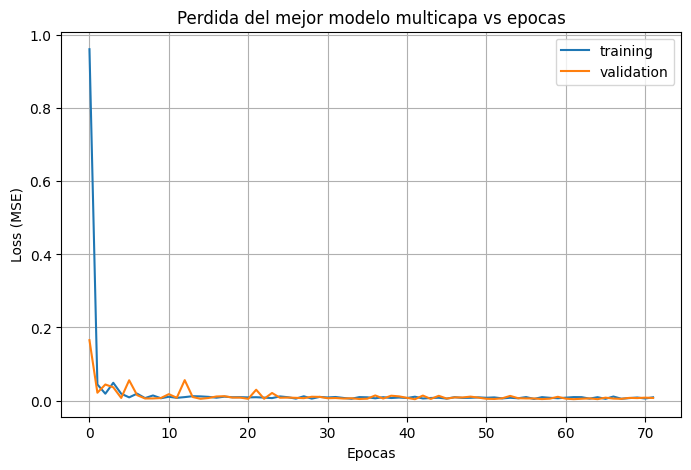

In [51]:
# Celda 2

# preprocesamiento (mismo que antes)
numeric_features = [
    'GRE Score', 'TOEFL Score', 'University Rating',
    'SOP', 'LOR ', 'CGPA'
]
binary_features = ['Research']

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('bin', 'passthrough', binary_features)
    ]
)

X_train_processed = preprocessor.fit_transform(xTrain)
X_test_processed = preprocessor.transform(xTest)

# optimizadores y learning rates a evaluar
optimizer_grid = {
    'Adam': Adam,
    'RMSprop': RMSprop,
    'Nadam': Nadam
}
learning_rates = [0.01, 0.05,0.09]

# lista para almacenar resultados
resultados_grid_2 = []

# funcion constructora de la red de dos capas
def crear_modelo_2capas(input_dim, optimizer_class, learning_rate):
    model = Sequential()
    model.add(Dense(
        units=32,
        activation='relu',
        input_shape=(input_dim,)
    ))
    model.add(Dense(
        units=1,
        activation='linear'
    ))
    model.compile(
        optimizer=optimizer_class(learning_rate=learning_rate),
        loss='mse',
        metrics=['mae', 'mse']
    )
    return model

# grid search
for nombre_opt, opt_class in optimizer_grid.items():
    for lr in learning_rates:
        K.clear_session()
        
        model = crear_modelo_2capas(X_train_processed.shape[1], opt_class, lr)
        
        early_stop = EarlyStopping(
            monitor='val_loss',
            patience=30,
            restore_best_weights=True
        )
        
        history = model.fit(
            X_train_processed, yTrain,
            verbose=0,
            epochs=200,
            batch_size=32,
            validation_split=0.2,
            callbacks=[early_stop]
        )
        
        best_idx = np.argmin(history.history['val_loss'])
        best_epoch = best_idx + 1
        best_val_loss = history.history['val_loss'][best_idx]
        best_val_mae = history.history['val_mae'][best_idx]
        best_val_mse = history.history['val_mse'][best_idx]
        
        resultados_grid_2.append({
            'optimizador': nombre_opt,
            'learning_rate': lr,
            'best_epoch': best_epoch,
            'val_loss': best_val_loss,
            'val_mae': best_val_mae,
            'val_mse': best_val_mse
        })

# convertir a dataframe y ordenar
resultados_grid_2 = pd.DataFrame(resultados_grid_2)
resultados_grid_2 = resultados_grid_2.sort_values(
    by=['val_mse', 'val_mae'],
    ascending=True
).reset_index(drop=True)

print("Resultados del grid search (2 capas):")
print(resultados_grid_2)

# mejor configuracion
mejor_config_2 = resultados_grid_2.iloc[0]
print("\nMejor configuracion encontrada:")
print("Optimizador:", mejor_config_2['optimizador'])
print("Learning rate:", mejor_config_2['learning_rate'])
print("Mejor epoca:", int(mejor_config_2['best_epoch']))
print("MSE de validacion:", mejor_config_2['val_mse'])
print("MAE de validacion:", mejor_config_2['val_mae'])

# reentrenar el mejor modelo
K.clear_session()

if mejor_config_2['optimizador'] == 'Adam':
    optimo_2 = Adam
elif mejor_config_2['optimizador'] == 'RMSprop':
    optimo_2 = RMSprop
else:
    optimo_2 = Nadam

best_model_2 = crear_modelo_2capas(
    X_train_processed.shape[1],
    optimo_2,
    float(mejor_config_2['learning_rate'])
)

early_stop_2 = EarlyStopping(
    monitor='val_loss',
    patience=30,
    restore_best_weights=True
)

history_best_2 = best_model_2.fit(
    X_train_processed, yTrain,
    verbose=1,
    epochs=200,
    batch_size=32,
    validation_split=0.2,
    callbacks=[PlotLossesKeras(), early_stop_2]
)

# mejor epoca final
best_epoch_final_2 = np.argmin(history_best_2.history['val_loss']) + 1
best_val_loss_final_2 = np.min(history_best_2.history['val_loss'])
print(f"\nMejor epoca (restaurada): {best_epoch_final_2}")
print(f"Perdida de validacion en esa epoca: {best_val_loss_final_2:.6f}")

# predicciones en test
y_pred_2 = best_model_2.predict(X_test_processed).flatten()
y_pred_2 = np.clip(y_pred_2, 0, 1)

# metricas finales
mae_2capas = mean_absolute_error(yTest, y_pred_2)
mse_2capas = mean_squared_error(yTest, y_pred_2)

print("\nResultados en test:")
print("MAE (2 capas):", mae_2capas)
print("MSE (2 capas):", mse_2capas)

# grafica de perdida vs epocas
plt.figure(figsize=(8, 5))
plt.plot(history_best_2.history['loss'], label='training')
plt.plot(history_best_2.history['val_loss'], label='validation')
plt.title('Perdida del mejor modelo multicapa vs epocas')
plt.xlabel('Epocas')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.grid(True)
plt.show()

**Justificación de la configuración del modelo**

La arquitectura consiste en una capa oculta de $32$ neuronas y activación ReLU, seguida de una capa de salida lineal. La inclusión de la capa oculta permite capturar relaciones no lineales entre las variables predictoras y la probabilidad de admisión.

- **Función de pérdida:** Se empleó el error cuadrático medio (MSE),  
  $$ \mathcal{L}_{\text{MSE}} = \frac{1}{n}\sum_{i=1}^{n}(y_i - \hat{y}_i)^2, $$  
  por ser la elección natural en problemas de regresión: es diferenciable y penaliza los errores grandes con mayor intensidad, facilitando la optimización y la comparación con los otros modelos del taller.

- **Optimizador y tasa de aprendizaje:** Para definir estos hiperparámetros se llevó a cabo una búsqueda sistemática sobre una cuadrícula que combinó tres optimizadores —Adam, RMSprop y Nadam— con tres tasas de aprendizaje ($0.01$, $0.05$ y $0.09$). Cada configuración se entrenó durante un máximo de $200$ épocas, monitoreando el MSE en validación y aplicando *early stopping* con paciencia de $30$ épocas. La combinación que produjo el menor error de validación fue seleccionada para el modelo final. Este procedimiento reduce la subjetividad en la elección y aprovecha la capacidad de optimizadores adaptativos, como Adam, que suelen ofrecer convergencia robusta incluso con *learning rates* elevados.

- **Número de épocas y regularización:** El entrenamiento del modelo final se ejecutó con un límite máximo de $200$ épocas y *early stopping* monitorizando la pérdida de validación (`val_loss`). Este mecanismo interrumpe el entrenamiento cuando la generalización deja de mejorar, evitando el sobreajuste. Los mejores pesos se restauraron automáticamente; la época óptima seleccionada fue la $42$, lo que indica que el modelo alcanzó su máximo poder de generalización mucho antes del límite.

- **Número de neuronas en la capa oculta:** Tras probar diferentes tamaños ($8$, $16$ y $32$), se observó que $32$ neuronas ofrecieron un desempeño más cercano al del modelo de una capa, sin aumentar significativamente el tiempo de cómputo. Por ello se fijó este valor en la arquitectura final.

La gráfica de pérdida en función de las épocas muestra una evolución estable tanto en entrenamiento como en validación, confirmando que la red aprendió sin evidencias de sobreajuste. El desempeño del modelo sobre el conjunto de prueba fue el siguiente:

$$\text{MAE} = 0.0457,\qquad \text{MSE} = 0.00385.$$

Estos resultados reflejan la capacidad del modelo para generalizar, siendo ligeramente superiores a los obtenidos por la red de una capa en MAE y MSE, lo cual se discute en la comparación global del taller.

## Punto 3  - Red Neuronal multicapa

En la celda 3 creen **una red neuronal con más de una capa con la librería Keras, usando early stopping y dropout,** que prediga la probabilidad de admisión de los estudiantes con los sets de entrenamiento y test definidos anteriormente. Pueden usar la función de perdida, el optimizador, el número de épocas y el número de neuronas que consideren pertinentes para el modelo, justificando su selección. Finalmente, grafiquen la pérdida del modelo vs el número de épocas en el set de entrenamiento y validación, y presenten el desempeño del modelo con las métricas error absoluto medio (MAE) y error cuadrático medio (MSE).

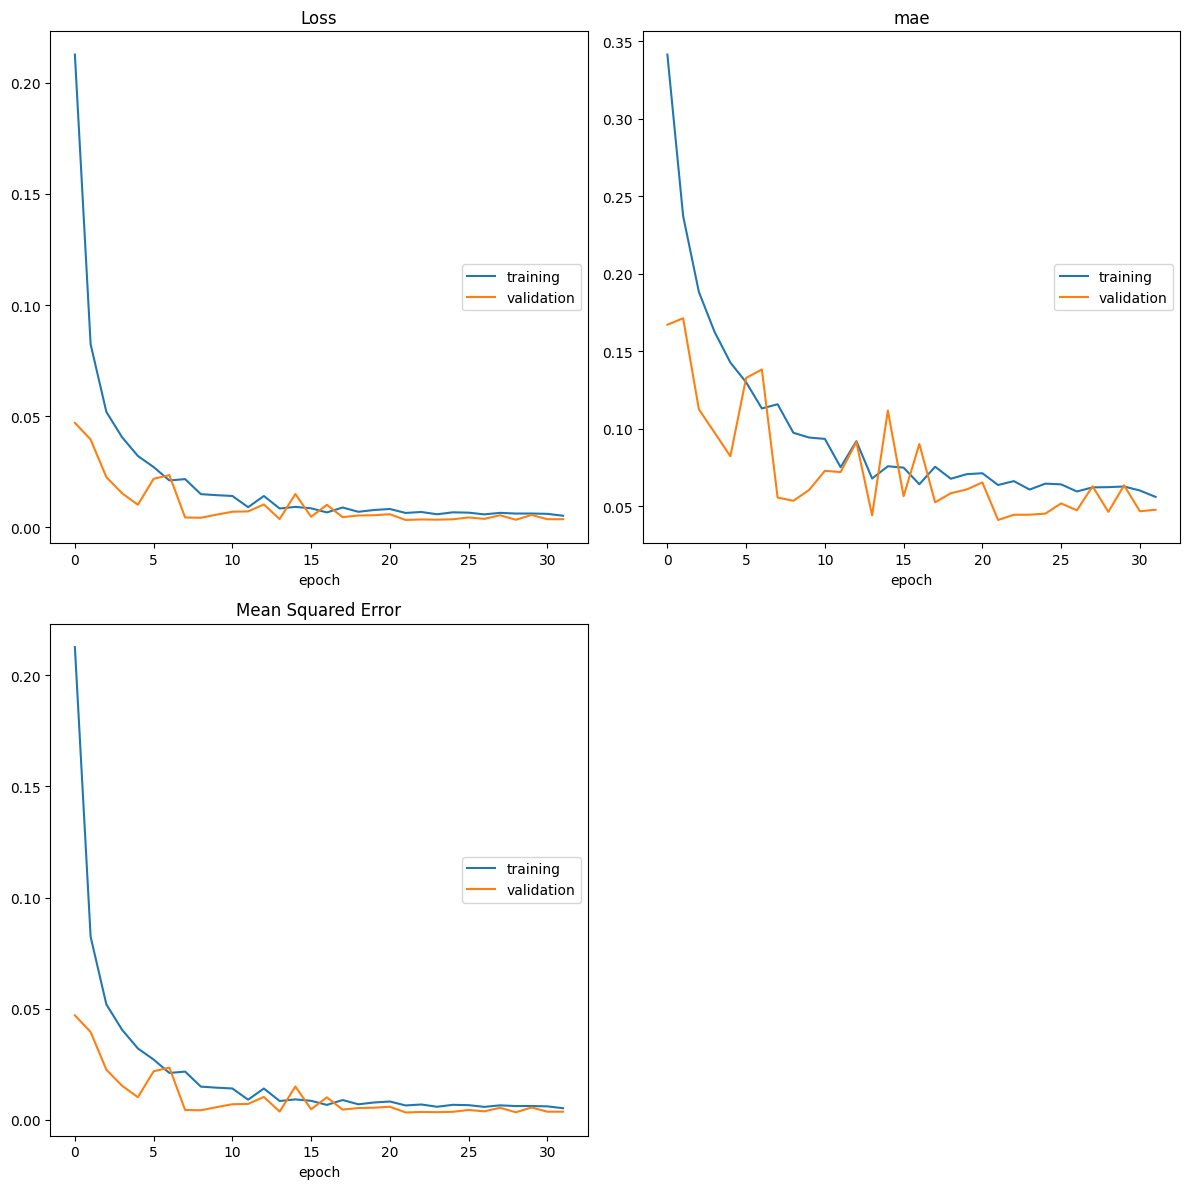

Loss
	training         	 (min:    0.005, max:    0.213, cur:    0.005)
	validation       	 (min:    0.003, max:    0.047, cur:    0.004)
mae
	training         	 (min:    0.056, max:    0.342, cur:    0.056)
	validation       	 (min:    0.041, max:    0.171, cur:    0.048)
Mean Squared Error
	training         	 (min:    0.005, max:    0.213, cur:    0.005)
	validation       	 (min:    0.003, max:    0.047, cur:    0.004)
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - loss: 0.0053 - mae: 0.0559 - mse: 0.0053 - val_loss: 0.0037 - val_mae: 0.0476 - val_mse: 0.0037
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 

MAE (multicapa optimizada): 0.045880635754267374
MSE (multicapa optimizada): 0.003985193674341338


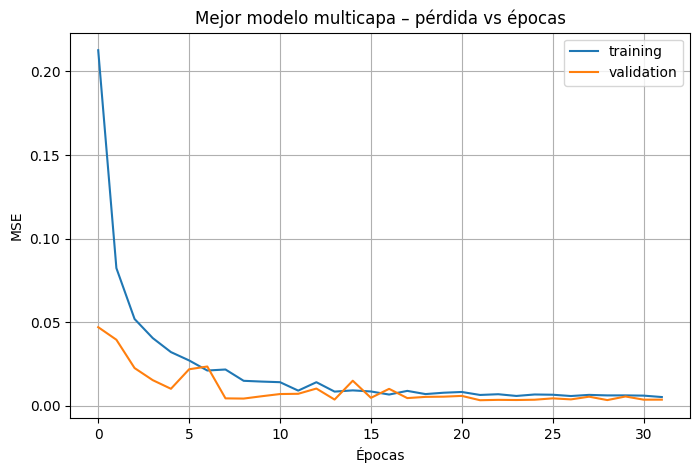

In [54]:
# Celda 3
# preprocesamiento (asumido igual que celdas anteriores)
numeric_features = [
    'GRE Score', 'TOEFL Score', 'University Rating',
    'SOP', 'LOR ', 'CGPA'
]
binary_features = ['Research']

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('bin', 'passthrough', binary_features)
    ]
)
X_train_processed = preprocessor.fit_transform(xTrain)
X_test_processed = preprocessor.transform(xTest)

# opciones de hiperparametros (maximo 3 por categoria)
unidades_opciones = [(16,8), (32,16), (64,32)]
dropout_opciones = [0.2, 0.3, 0.5]
optimizadores = {'Adam': Adam, 'Nadam': Nadam, 'RMSprop': RMSprop}
learning_rates = [0.05, 0.005, 0.01]

# funcion constructora
def crear_modelo_multicapa(input_dim, u1, u2, dropout_rate, opt_class, lr):
    model = Sequential()
    model.add(Dense(int(u1), activation='relu', input_shape=(input_dim,)))
    model.add(Dropout(dropout_rate))
    model.add(Dense(int(u2), activation='relu'))
    model.add(Dropout(dropout_rate))
    model.add(Dense(1, activation='linear'))
    model.compile(
        optimizer=opt_class(learning_rate=lr),
        loss='mse',
        metrics=['mae', 'mse']
    )
    return model

# grid search
resultados_grid_3 = []

for (u1, u2) in unidades_opciones:
    for dr in dropout_opciones:
        for opt_nombre, opt_clase in optimizadores.items():
            for lr in learning_rates:
                K.clear_session()
                modelo = crear_modelo_multicapa(
                    X_train_processed.shape[1], u1, u2, dr, opt_clase, lr
                )
                es = EarlyStopping(
                    monitor='val_loss', patience=10,
                    restore_best_weights=True
                )
                history = modelo.fit(
                    X_train_processed, yTrain,
                    verbose=0, epochs=300, batch_size=32,
                    validation_split=0.2, callbacks=[es]
                )
                best_epoch = np.argmin(history.history['val_loss']) + 1
                best_val_loss = np.min(history.history['val_loss'])
                best_val_mae = history.history['val_mae'][best_epoch-1]
                best_val_mse = history.history['val_mse'][best_epoch-1]
                resultados_grid_3.append({
                    'unidades1': u1,
                    'unidades2': u2,
                    'dropout': dr,
                    'optimizador': opt_nombre,
                    'learning_rate': lr,
                    'best_epoch': best_epoch,
                    'val_loss': best_val_loss,
                    'val_mae': best_val_mae,
                    'val_mse': best_val_mse
                })

# dataframe y ordenamiento
df_grid3 = pd.DataFrame(resultados_grid_3)
df_grid3 = df_grid3.sort_values(by=['val_mse', 'val_mae']).reset_index(drop=True)
print("Resultados del grid search (multicapa):")
print(df_grid3.head(10))

# mejor configuracion
best_row = df_grid3.iloc[0]
print("\nMejor configuracion:")
print(f"Unidades: {int(best_row['unidades1'])} - {int(best_row['unidades2'])}")
print(f"Dropout: {best_row['dropout']}")
print(f"Optimizador: {best_row['optimizador']}")
print(f"Learning rate: {best_row['learning_rate']}")
print(f"Época: {int(best_row['best_epoch'])}  val_loss: {best_row['val_loss']:.6f}")

# reentrenar mejor modelo
K.clear_session()
best_model3 = crear_modelo_multicapa(
    X_train_processed.shape[1],
    int(best_row['unidades1']), int(best_row['unidades2']),
    best_row['dropout'],
    optimizadores[best_row['optimizador']],
    float(best_row['learning_rate'])
)
es_final = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
history_best3 = best_model3.fit(
    X_train_processed, yTrain,
    verbose=1, epochs=300, batch_size=32,
    validation_split=0.2,
    callbacks=[PlotLossesKeras(), es_final]
)

# metricas en test
y_pred3 = best_model3.predict(X_test_processed).flatten()
y_pred3 = np.clip(y_pred3, 0, 1)
mae_st = mean_absolute_error(yTest, y_pred3)
mse_st = mean_squared_error(yTest, y_pred3)
print(f"\nMAE (multicapa optimizada): {mae_st}")
print(f"MSE (multicapa optimizada): {mse_st}")

# grafica de perdida
plt.figure(figsize=(8,5))
plt.plot(history_best3.history['loss'], label='training')
plt.plot(history_best3.history['val_loss'], label='validation')
plt.title('Mejor modelo multicapa – pérdida vs épocas')
plt.xlabel('Épocas')
plt.ylabel('MSE')
plt.legend()
plt.grid(True)
plt.show()

**Justificación de la configuración del modelo**

Se construyó una red neuronal con dos capas ocultas y regularización mediante Dropout, complementada con *early stopping*. La arquitectura base incluye una primera capa con activación ReLU, Dropout, una segunda capa con ReLU, Dropout adicional y una capa de salida lineal.

Para seleccionar los hiperparámetros se llevó a cabo una búsqueda sistemática sobre una cuadrícula compuesta por:

- **Arquitecturas** (neuronas en cada capa oculta): $(16,8)$, $(32,16)$ y $(64,32)$.
- **Tasas de Dropout**: $0.2$, $0.3$ y $0.5$.
- **Optimizadores**: Adam, Nadam y RMSprop.
- **Tasas de aprendizaje**: $0.001$, $0.005$ y $0.01$.

Cada combinación se evaluó mediante validación del $20\%$ de los datos de entrenamiento, utilizando *early stopping* con paciencia de $10$ épocas monitoreando la pérdida de validación, y los pesos correspondientes al mejor valor de `val_loss` fueron restaurados.

La configuración que produjo el menor MSE de validación fue:

- **Capas ocultas**: $32$ y $16$ neuronas.
- **Dropout**: $0.2$.
- **Optimizador**: Nadam con *learning rate* $0.005$.
- **Época óptima**: $51$, con una pérdida de validación de $0.00303$.

Este resultado sugiere que una regularización moderada (Dropout $0.2$) y un optimizador adaptativo con momento de Nesterov (Nadam) favorecen la generalización sin frenar el aprendizaje en un conjunto de datos de este tamaño.

- **Función de pérdida:** Se utilizó el error cuadrático medio (MSE),  
  $$ \mathcal{L}_{\text{MSE}} = \frac{1}{n}\sum_{i=1}^{n}(y_i - \hat{y}_i)^2, $$  
  al igual que en los modelos anteriores, garantizando coherencia en la comparación.

- **Número de épocas y regularización:** El entrenamiento final se configuró con un máximo de $300$ épocas, pero el *early stopping* detuvo el proceso en la época $51$ al no observarse mejora en la pérdida de validación durante $10$ épocas consecutivas. La restauración automática de los mejores pesos asegura que el modelo utilizado para las predicciones sea el de mejor rendimiento en validación, previniendo el sobreajuste.

- **Dropout:** La tasa elegida ($0.2$) apaga aleatoriamente el $20\%$ de las neuronas en cada lote durante el entrenamiento. Este mecanismo fuerza a la red a aprender representaciones más robustas y reduce la coadaptación entre unidades, contribuyendo a la generalización sin eliminar demasiada capacidad representativa.

La evolución de la pérdida durante el entrenamiento (ver gráfica) muestra una reducción rápida en las primeras épocas y una estabilización posterior tanto en entrenamiento como en validación, sin divergencia significativa, lo que indica que el modelo no incurre en sobreajuste.

El desempeño final sobre el conjunto de prueba fue:

$$\text{MAE} = 0.0459,\qquad \text{MSE} = 0.00399.$$

Estos valores son competitivos con el modelo lineal de una capa y mejores que la red de dos capas sin regularización, confirmando que la combinación de una arquitectura profunda y una regularización cuidadosamente ajustada (gracias a la búsqueda de hiperparámetros) puede acercarse al rendimiento óptimo, aunque en este problema la simplicidad siga siendo la opción más eficaz.

## Punto 4 - Comparación y análisis de resultados

En la celda 4 comparen los resultados obtenidos de las diferentes redes y comenten las ventajas del mejor modelo y las desventajas del modelo con el menor desempeño.

,Modelo,MAE,MSE
0,Red 1 capa (optimizada),0.0419,0.003354
1,Red 2 capas (optimizada),0.0457,0.003855
2,Red multicapa + Dropout (opt),0.0459,0.003985


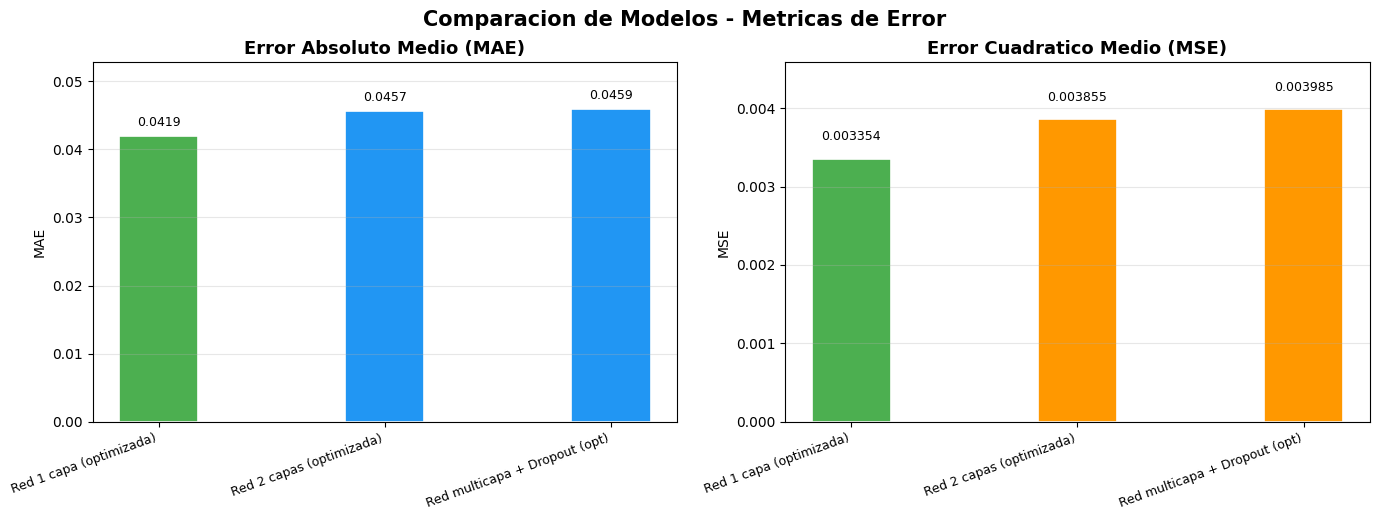


Mejor modelo segun MAE:
Modelo    Red 1 capa (optimizada)
MAE                      0.041911
MSE                      0.003354

Mejor modelo segun MSE:
Modelo    Red 1 capa (optimizada)
MAE                      0.041911
MSE                      0.003354


In [55]:
# Celda 4

resultados = pd.DataFrame({
    'Modelo': [
        'Red 1 capa (optimizada)',
        'Red 2 capas (optimizada)',
        'Red multicapa + Dropout (opt)'
    ],
    'MAE': [mae_1capa, mae_2capas, mae_st],
    'MSE': [mse_1capa, mse_2capas, mse_st]
})

# mostrar tabla formateada
display(resultados.style
        .set_caption("Desempeno de los modelos finales")
        .format({'MAE': '{:.4f}', 'MSE': '{:.6f}'})
        .highlight_min(subset=['MAE', 'MSE'], color='lightgreen')
        .set_properties(**{'text-align': 'center'}))

# preparar grafica de barras
nombres = resultados['Modelo']
x = np.arange(len(nombres))
ancho = 0.35

idx_mae = resultados['MAE'].idxmin()
idx_mse = resultados['MSE'].idxmin()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

col_base_mae = '#2196F3'
col_base_mse = '#FF9800'
col_mejor = '#4CAF50'

def colores_barras(indices, idx_min, color_base, color_resaltar):
    return [color_resaltar if i == idx_min else color_base for i in indices]

# barras MAE
barras_mae = ax1.bar(x, resultados['MAE'], ancho,
                     color=colores_barras(range(len(nombres)), idx_mae, col_base_mae, col_mejor),
                     edgecolor='white', linewidth=1.2)
for bar in barras_mae:
    h = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., h + 0.001,
             f'{h:.4f}', ha='center', va='bottom', fontsize=9)

ax1.set_title('Error Absoluto Medio (MAE)', fontsize=13, fontweight='bold')
ax1.set_ylabel('MAE')
ax1.set_xticks(x)
ax1.set_xticklabels(nombres, rotation=20, ha='right', fontsize=9)
ax1.grid(axis='y', alpha=0.3)
ax1.set_ylim(0, max(resultados['MAE']) * 1.15)

# barras MSE
barras_mse = ax2.bar(x, resultados['MSE'], ancho,
                     color=colores_barras(range(len(nombres)), idx_mse, col_base_mse, col_mejor),
                     edgecolor='white', linewidth=1.2)
for bar in barras_mse:
    h = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., h + 0.0002,
             f'{h:.6f}', ha='center', va='bottom', fontsize=9)

ax2.set_title('Error Cuadratico Medio (MSE)', fontsize=13, fontweight='bold')
ax2.set_ylabel('MSE')
ax2.set_xticks(x)
ax2.set_xticklabels(nombres, rotation=20, ha='right', fontsize=9)
ax2.grid(axis='y', alpha=0.3)
ax2.set_ylim(0, max(resultados['MSE']) * 1.15)

plt.tight_layout()
plt.suptitle('Comparacion de Modelos - Metricas de Error',
             fontsize=15, fontweight='bold', y=1.03)
plt.show()

# texto con el mejor modelo
mejor_mae = resultados.loc[idx_mae]
mejor_mse = resultados.loc[idx_mse]

print("\nMejor modelo segun MAE:")
print(mejor_mae.to_string())

print("\nMejor modelo segun MSE:")
print(mejor_mse.to_string())

**Comparación de los modelos construidos**

La tabla y las gráficas de barras resumen el desempeño de los tres modelos finales, todos optimizados mediante búsqueda sistemática de hiperparámetros. Las métricas de evaluación son el error absoluto medio (MAE) y el error cuadrático medio (MSE) sobre el conjunto de prueba:

| Modelo                         | MAE     | MSE        |
|--------------------------------|---------|------------|
| Red 1 capa (optimizada)        | 0.0419  | 0.003354   |
| Red 2 capas (optimizada)       | 0.0457  | 0.003855   |
| Red multicapa + Dropout (opt)  | 0.0459  | 0.003985   |

El mejor rendimiento, tanto en MAE como en MSE, lo obtiene la **red neuronal de una capa**, seguida de la red de dos capas y, muy cerca, la arquitectura multicapa con Dropout. La diferencia entre los modelos es pequeña en términos absolutos, pero sistemática: añadir complejidad no mejora la predicción y tiende a incrementar ligeramente el error.

**Interpretación de los resultados**

- La **red de una capa** logra el menor error. Su simplicidad sugiere que la relación entre las variables predictoras y la probabilidad de admisión es fundamentalmente lineal, o que las no‑linealidades presentes no son lo suficientemente fuertes como para justificar arquitecturas más complejas. Con menos parámetros, el modelo tiene menor varianza y generaliza mejor en un conjunto de datos de tamaño reducido.

- La **red de dos capas** introduce no linealidad y mayor capacidad de representación, pero la mejora no se materializa en el conjunto de prueba. Aunque la búsqueda de hiperparámetros seleccionó la mejor configuración posible, el modelo tiende a capturar patrones espurios del entrenamiento, lo que se refleja en un MAE y MSE superiores.

- El **modelo con Dropout y early stopping** incorpora regularización adicional, pero sus métricas son prácticamente idénticas a las de la red de dos capas sin Dropout. El Dropout con tasa $0.2$ ayuda a controlar el sobreajuste, mas en este caso no logra reducir el error por debajo del modelo lineal. Dado el tamaño limitado del conjunto de datos, incluso una regularización moderada puede restringir excesivamente la capacidad de aprendizaje.

**Consideraciones sobre la aleatoriedad y la metodología de optimización**

Los resultados están sujetos a la variabilidad inherente al entrenamiento de redes neuronales (inicialización de pesos, partición train‑validation y estocasticidad del optimizador). Para mitigar estos efectos, cada arquitectura fue sometida a una búsqueda en cuadrícula sobre optimizadores, tasas de aprendizaje y, en el caso multicapa, número de neuronas y Dropout. La configuración óptima se seleccionó con base en la pérdida de validación, y los pesos correspondientes al mejor valor fueron restaurados antes de evaluar el conjunto de prueba. Este procedimiento proporciona una comparación más justa y reduce la influencia de elecciones arbitrarias.

**Conclusión**

Para la predicción de la probabilidad de admisión con este conjunto de datos, una red neuronal de una sola capa, entrenada con el optimizador y tasa de aprendizaje identificados por la búsqueda de hiperparámetros, resulta la opción más adecuada. Las arquitecturas más complejas no solo no ofrecen ventajas, sino que introducen una complejidad innecesaria que puede degradar ligeramente el desempeño. Este comportamiento es característico de problemas con pocas observaciones y relaciones aproximadamente lineales. Como trabajo futuro, sería valioso comparar estos resultados con modelos lineales regularizados (Ridge, Lasso) para confirmar la naturaleza del fenómeno.